## Project Goals

The goal of this project is to explore the relationship between GDP and life expectancy 
for six countries over time. Using data from the World Health Organization and the World Bank,
I will analyze trends, visualize relationships, and identify correlations between economic 
growth and population health.


## Research Questions

1. Has life expectancy increased over time in the six nations?
2. Has GDP increased over time in the six nations?
3. Is there a correlation between GDP and life expectancy?
4. What is the average life expectancy for each country?
5. How is life expectancy distributed across countries?


In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# load Data
df = pd.read_csv("all_data.csv")

In [4]:
# Inspect Data
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [5]:
# Inspect Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [6]:
# Inspect Data
df.describe()

,Year,Life expectancy at birth (years),GDP
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


The dataset contains GDP and life expectancy data by country and year. 
There are no missing values, and GDP values vary widely between countries.

In [7]:
# Renaming Columns
df.columns = [
    "country",
    "year",
    "life_expectancy",
    "gdp"
]

In [8]:
#Checking Missing Values
df.isnull().sum()

country            0
year               0
life_expectancy    0
gdp                0
dtype: int64

In [9]:
# Checking Countries
df["country"].unique()

array(['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
       'Zimbabwe'], dtype=object)

The dataset includes six countries observed across multiple years.

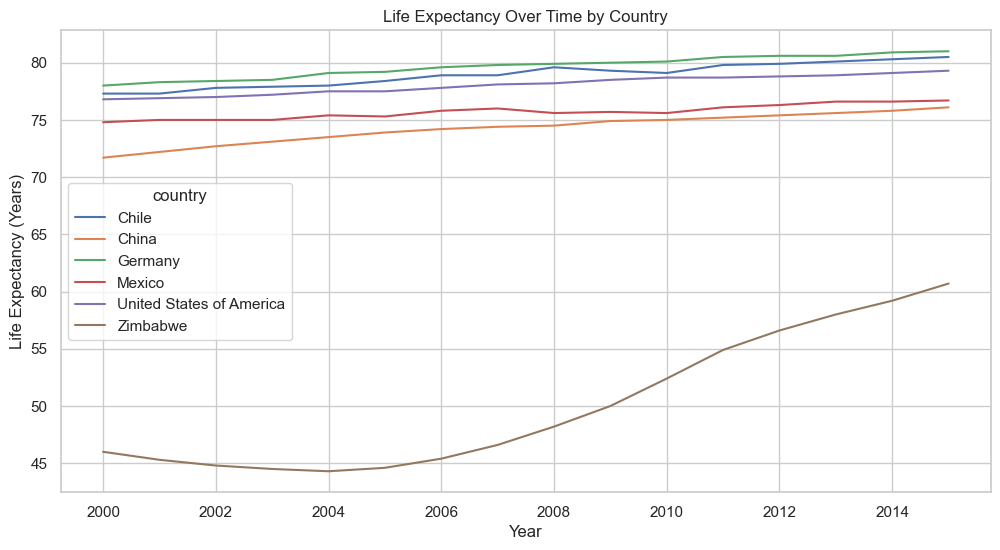

In [10]:
# Life Expectancy Over Time.
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="year", y="life_expectancy", hue="country")

plt.title("Life Expectancy Over Time by Country")
plt.ylabel("Life Expectancy (Years)")
plt.xlabel("Year")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "life_expectancy_over_time.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

Life expectancy has generally increased over time for all six countries,
though the rate of increase varies.

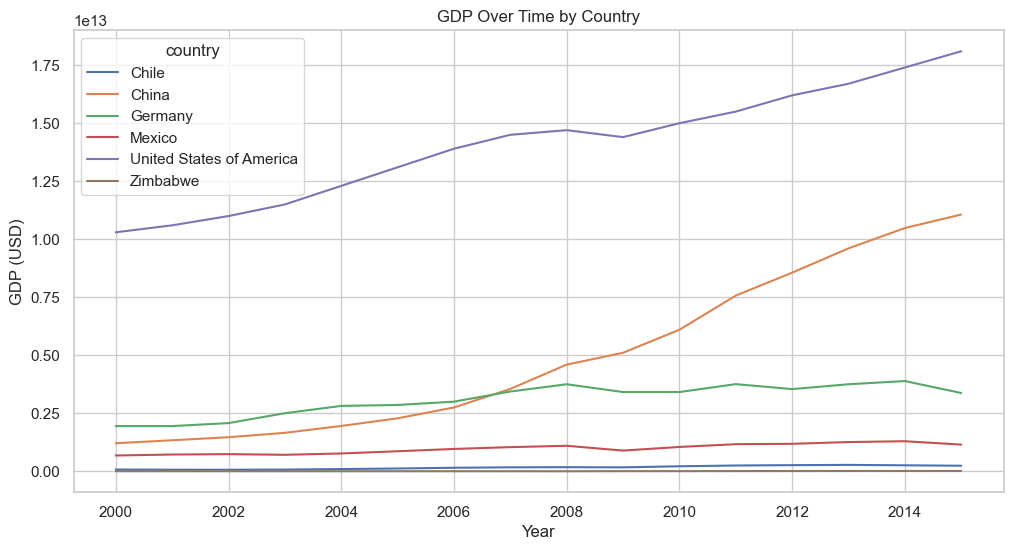

In [11]:
# GDP over time
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="year", y="gdp", hue="country")

plt.title("GDP Over Time by Country")
plt.ylabel("GDP (USD)")
plt.xlabel("Year")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "gdp_over_time.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

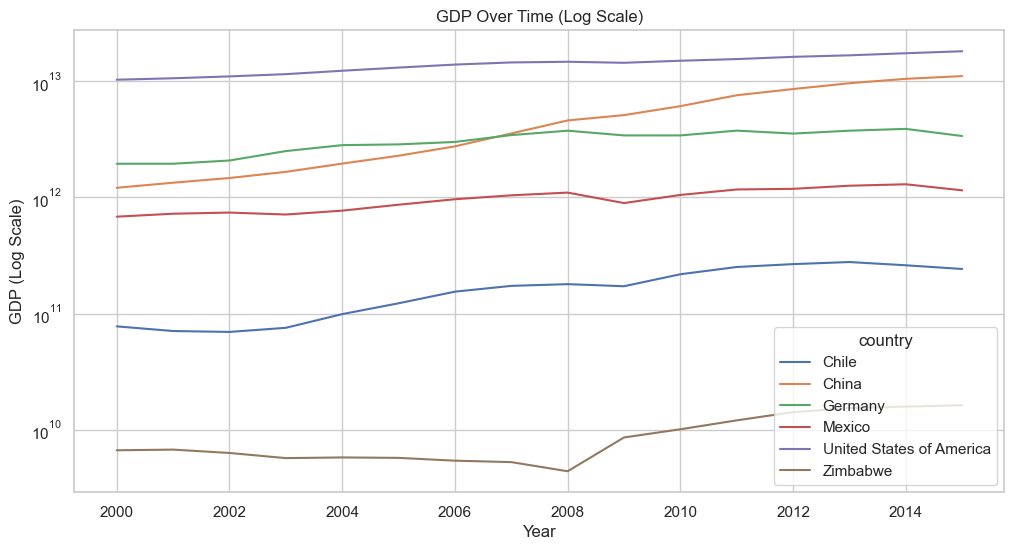

In [12]:
# GDP long-scale
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="year", y="gdp", hue="country")

plt.yscale("log")
plt.title("GDP Over Time (Log Scale)")
plt.xlabel("Year")
plt.ylabel("GDP (Log Scale)")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "gdp_over_time_log_scale.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

GDP has increased for most countries, but at very different magnitudes.
Using a logarithmic scale makes trends clearer.

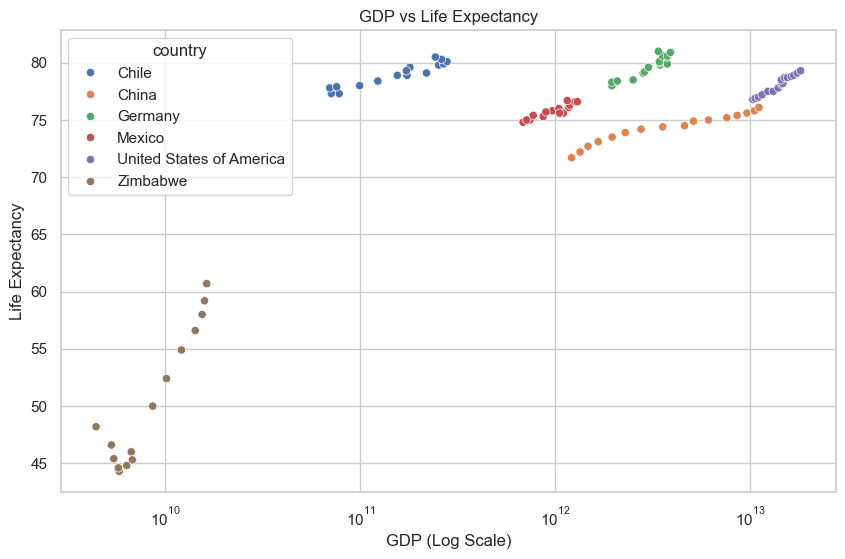

In [13]:
# Scatter-plot
sns.scatterplot(data=df, x="gdp", y="life_expectancy", hue="country")

plt.xscale("log")
plt.title("GDP vs Life Expectancy")
plt.xlabel("GDP (Log Scale)")
plt.ylabel("Life Expectancy")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "gdp_vs_life_expectancy_scatter.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

There is a positive relationship between GDP and life expectancy.
Higher GDP is generally associated with higher life expectancy.

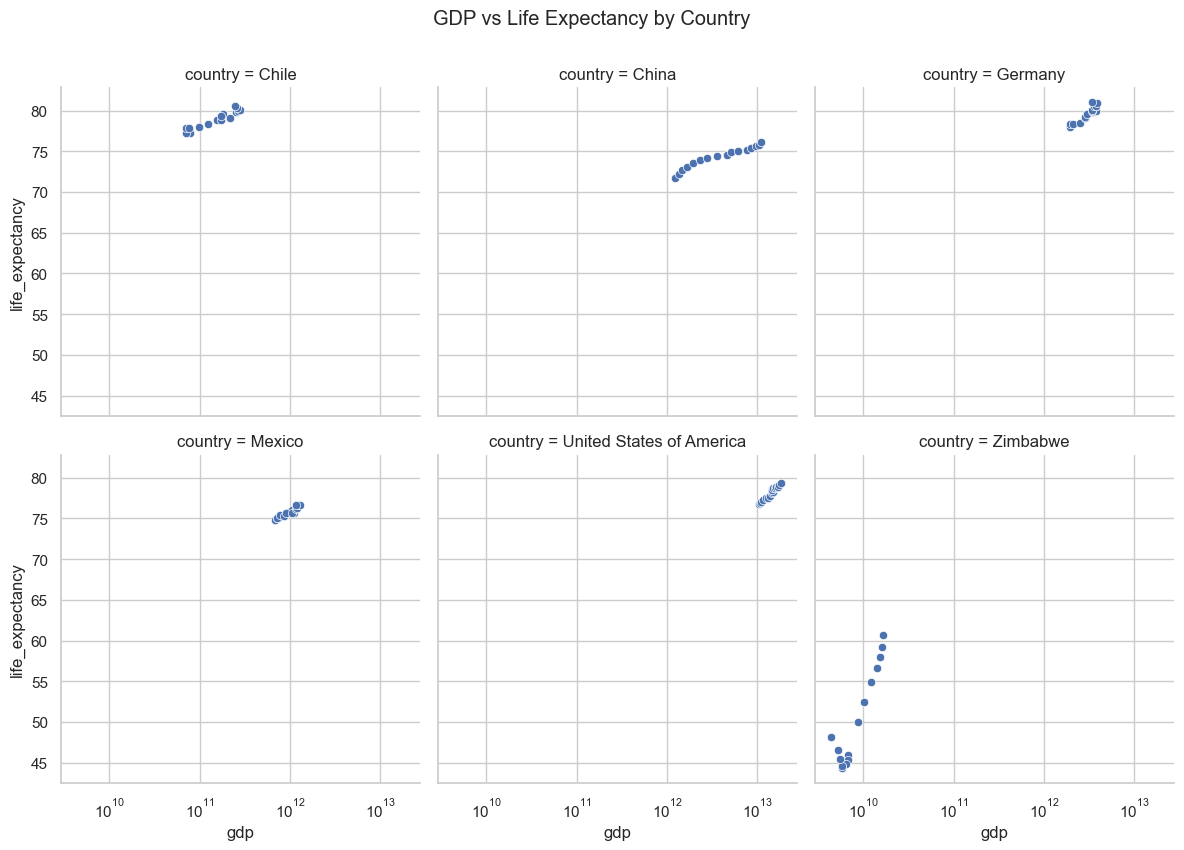

In [14]:
# Facet Grid
g = sns.FacetGrid(df, col="country", col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x="gdp", y="life_expectancy")

g.set(xscale="log")
g.fig.suptitle("GDP vs Life Expectancy by Country", y=1.05)

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "facet_gdp_vs_life_expectancy.png")

g.savefig(filepath, dpi=300, bbox_inches="tight")

plt.show()

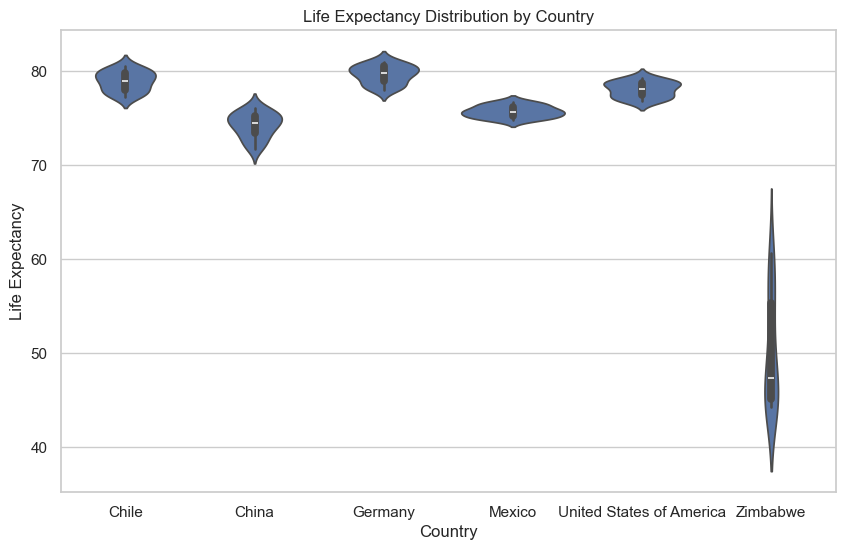

In [15]:
# Violin plot
sns.violinplot(data=df, x="country", y="life_expectancy")

plt.title("Life Expectancy Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Life Expectancy")

# Save to Image Folder
folder = "Image"
os.makedirs(folder, exist_ok=True)

filepath = os.path.join(folder, "life_expectancy_violin.png")

plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

Some countries show a wider distribution of life expectancy values,
indicating greater variability over time.

In [16]:
# average life expectency by country
df.groupby("country")["life_expectancy"].mean().reset_index()

,country,life_expectancy
0,Chile,78.94375
1,China,74.26250
2,Germany,79.65625
3,Mexico,75.71875
4,United States of America,78.06250
5,Zimbabwe,50.09375


In [17]:
# correlation between country and life-expectancy
df[["gdp", "life_expectancy"]].corr()

,gdp,life_expectancy
gdp,1.000000,0.343207
life_expectancy,0.343207,1.000000


There is a strong positive correlation between GDP and life expectancy
across the dataset.

## Conclusions

Throughout this project, I explored the relationship between economic growth
and life expectancy across six countries.

Key Findings:
- Life expectancy increased over time in all countries.
- GDP growth generally coincided with increases in life expectancy.
- There is a strong positive correlation between GDP and life expectancy.
- Countries with higher GDP tend to have higher and more stable life expectancy.

Limitations:
- GDP alone does not account for healthcare access, inequality, or public policy.
- Life expectancy is influenced by many social and environmental factors.

Future Research:
- Incorporate healthcare spending data
- Compare regional trends
- Analyze inequality metrics
